# Chapter 10: Prophet — Business Forecasting Tool

## Story: A Retail Manager’s Problem
Imagine a retail store manager trying to predict sales. Some days are normal, weekends are busy, and holidays bring spikes. Traditional models struggle to handle all these patterns together. Prophet makes this easy by combining trend, seasonality, and holidays automatically.

## Concept 1: Trend
Trend shows the overall direction (upward or downward).

Simple: Is your business growing or shrinking over time?

## Concept 2: Seasonality
Seasonality captures repeating patterns (daily, weekly, yearly).

Example: Higher sales on weekends.

## Concept 3: Holiday Effects
Special events cause spikes or drops.

Example: Black Friday increases sales dramatically.

## Prophet Forecasting on Google Stock Data (GOOG)
## Step 1: Install & Import Libraries

In [1]:
!pip install prophet yfinance --quiet

import pandas as pd
import numpy as np
import yfinance as yf
from prophet import Prophet
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Load Google Stock Data

In [2]:
# Download Google stock data
data = yf.download("GOOG", start="2020-01-01", end="2025-01-01")

# Prepare for Prophet (IMPORTANT format: ds, y)
df = data[['Close']].reset_index()
df.columns = ['ds', 'y']

df.head()

[*********************100%***********************]  1 of 1 completed


,ds,y
0,2020-01-02,67.811760
1,2020-01-03,67.479004
2,2020-01-06,69.142838
3,2020-01-07,69.099701
4,2020-01-08,69.644226


## Step 3: Visualize Data

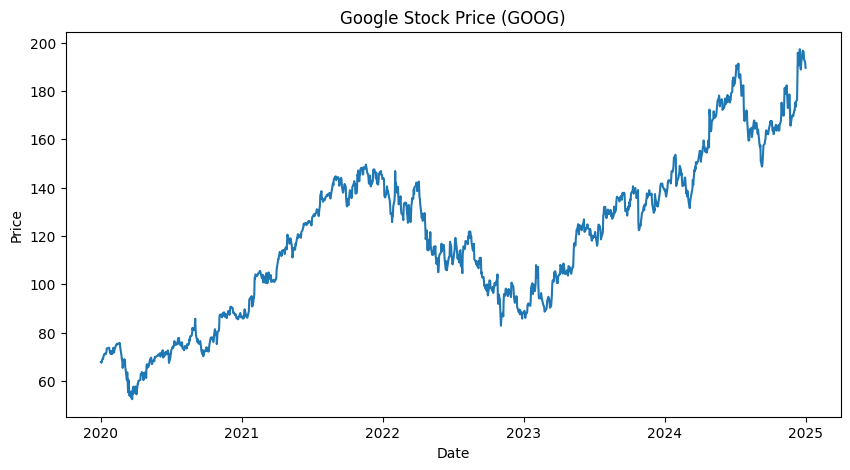

In [3]:
plt.figure(figsize=(10,5))
plt.plot(df['ds'], df['y'])
plt.title("Google Stock Price (GOOG)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Step 4: Train Prophet Model

In [4]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(df)

13:43:58 - cmdstanpy - INFO - Chain [1] start processing
13:43:59 - cmdstanpy - INFO - Chain [1] done processing


## Step 5: Make Future Predictions

In [5]:
future = model.make_future_dataframe(periods=90)  # next 90 days
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
1338,2025-03-22,187.646726,178.946031,195.269191
1339,2025-03-23,188.111015,180.165953,196.163563
1340,2025-03-24,191.784712,183.362505,200.266701
1341,2025-03-25,192.254414,184.122466,200.357904
1342,2025-03-26,192.624516,184.773179,201.206283
1343,2025-03-27,193.032133,185.110451,200.920944
1344,2025-03-28,193.583472,185.653615,201.393713
1345,2025-03-29,190.727942,182.283454,198.376559
1346,2025-03-30,191.110408,183.087482,199.616358
1347,2025-03-31,194.684016,186.707331,202.199562


## Step 6: Plot Forecast

c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


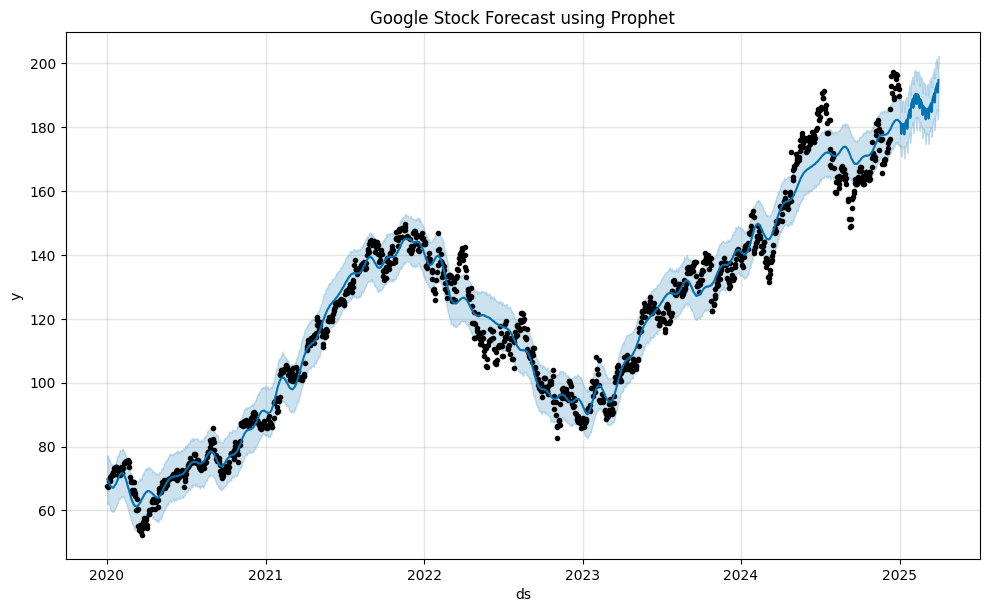

In [6]:
model.plot(forecast)
plt.title("Google Stock Forecast using Prophet")
plt.show()

## Step 7: Components (Trend + Seasonality)

c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series cont

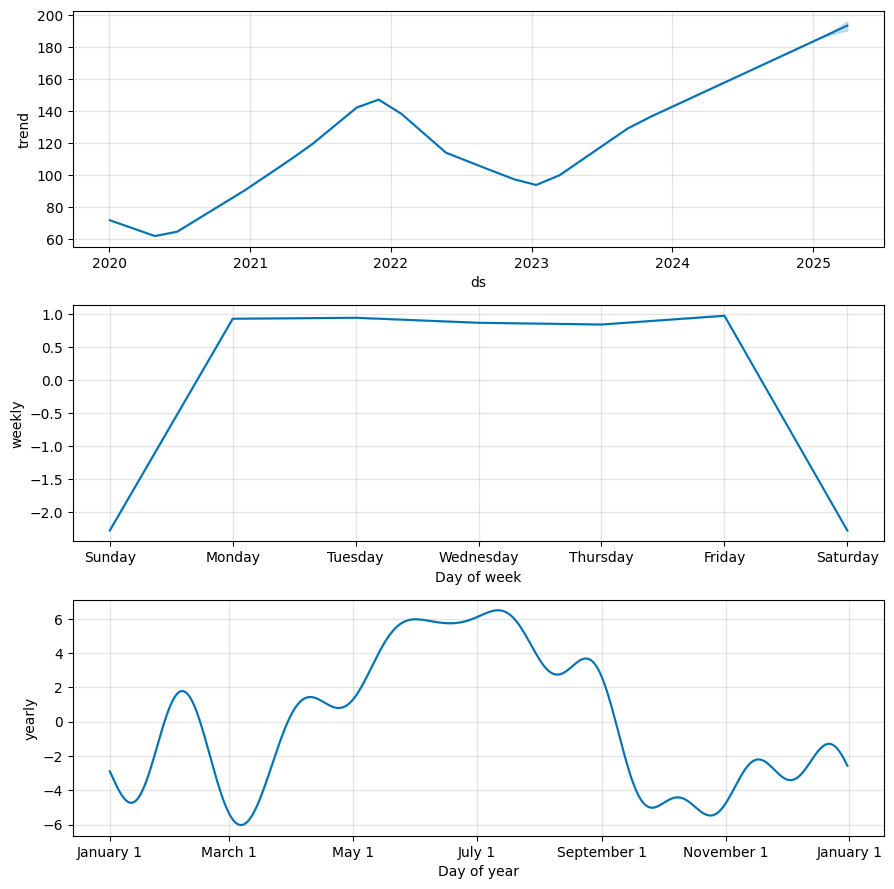

In [7]:
model.plot_components(forecast)
plt.show()

In [11]:
print("""
1. Trend → Long-term growth of Google stock (generally upward)
2. Weekly Seasonality → Small patterns across weekdays due to trading behavior
3. Yearly Seasonality → Cycles due to earnings, market conditions, and investor sentiment
""")


1. Trend → Long-term growth of Google stock (generally upward)
2. Weekly Seasonality → Small patterns across weekdays due to trading behavior
3. Yearly Seasonality → Cycles due to earnings, market conditions, and investor sentiment



## Summary
Prophet helps forecast Google stock by combining:
- Trend (long-term movement)
- Seasonality (weekly & yearly patterns)
- Uncertainty (confidence range)

This makes it a powerful tool for business and financial forecasting.


## Prophet Forecasting on Google Stock (Full Code in One Block)


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[*********************100%***********************]  1 of 1 completed


 Step 1: Libraries loaded successfully

 Step 2: Data loaded
Shape: (1258, 2)
Preview:
           ds          y
0 2020-01-02  67.811760
1 2020-01-03  67.479004
2 2020-01-06  69.142838
3 2020-01-07  69.099701
4 2020-01-08  69.644226

 Interpretation: Each row represents Google’s daily stock price (ds = date, y = price).


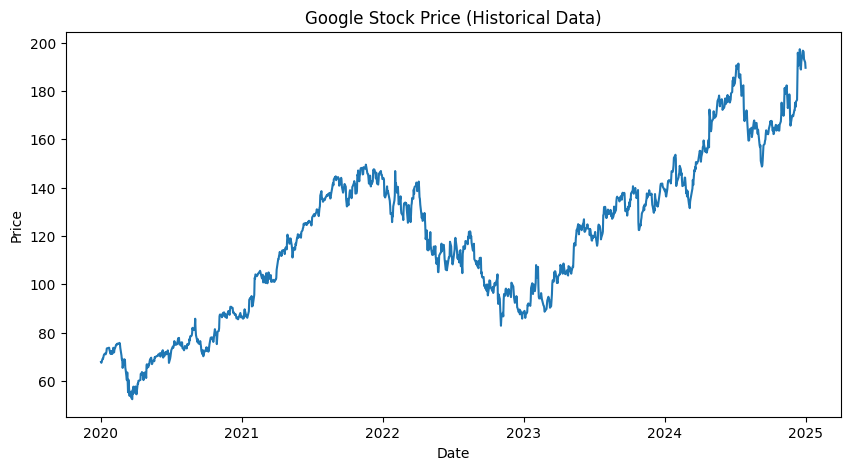


 The graph shows an overall upward trend with fluctuations, meaning the stock has long-term growth with short-term volatility.


14:12:29 - cmdstanpy - INFO - Chain [1] start processing
14:12:30 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',



 Step 4: Model trained successfully
Prophet has learned trend, seasonality, and noise patterns from the stock data.

 Step 5: Forecast generated

Sample Predictions:
             ds        yhat  yhat_lower  yhat_upper
1343 2025-03-27  193.032133  184.059750  201.069522
1344 2025-03-28  193.583472  185.658232  201.866344
1345 2025-03-29  190.727942  181.604772  198.593123
1346 2025-03-30  191.110408  182.738846  198.934212
1347 2025-03-31  194.684016  185.573969  203.012697

 Interpretation:
- yhat = predicted stock price
- yhat_lower / yhat_upper = uncertainty range
- This range shows possible market fluctuation risk


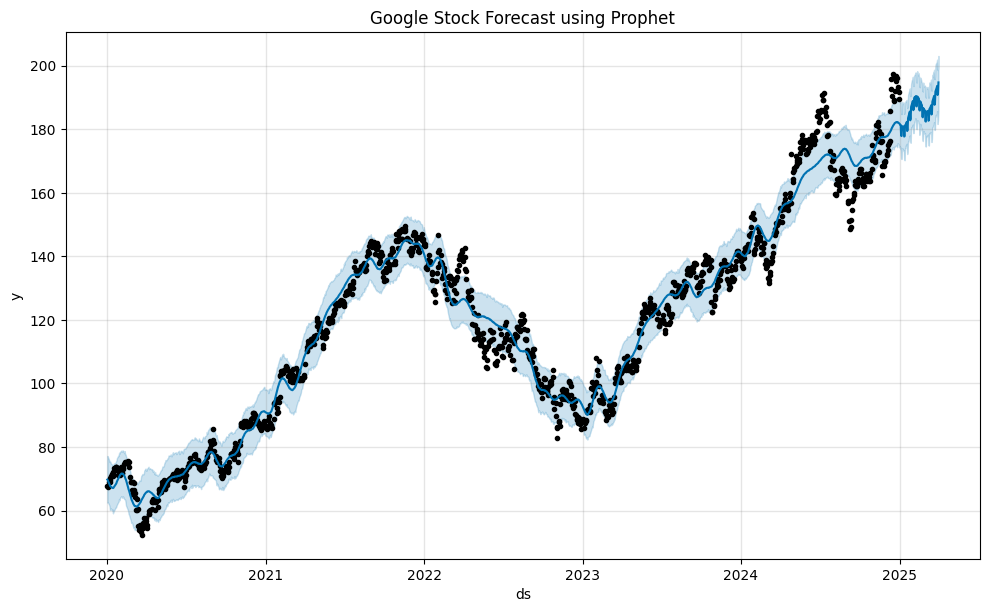

c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series cont


 Interpretation: Blue line shows predicted trend, shaded area shows uncertainty. Wider area means higher volatility.


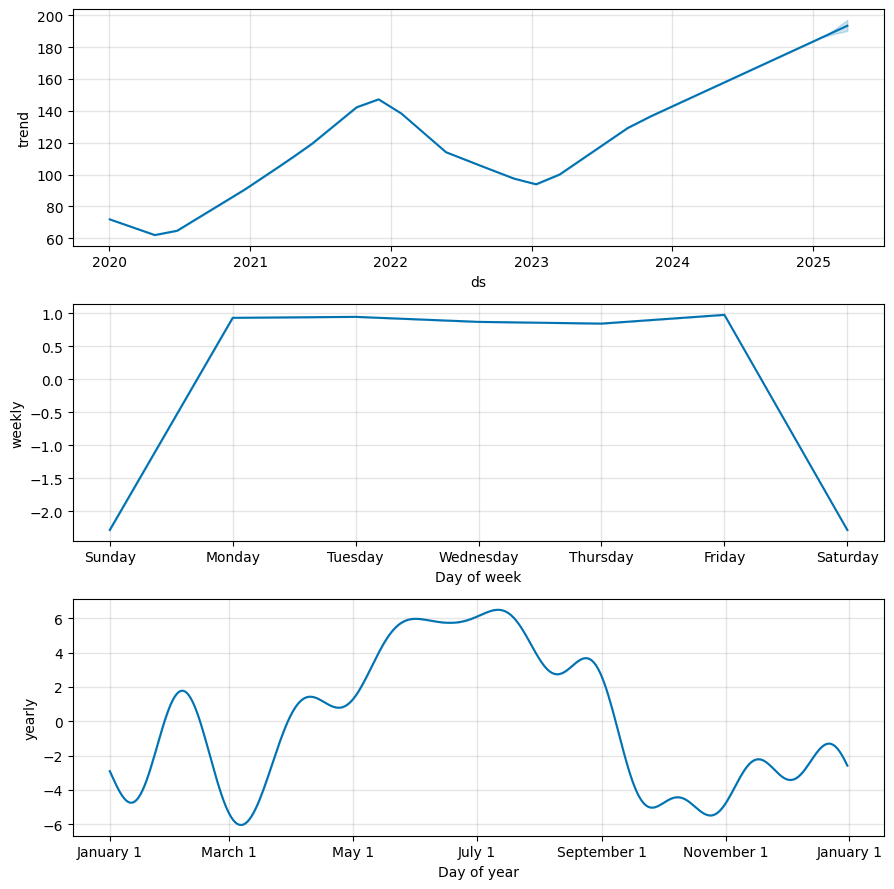


 Step 7: Components breakdown


In [13]:
# 1. INSTALL & IMPORT LIBRARIES
!pip install prophet yfinance --quiet
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from prophet import Prophet

print("\n Step 1: Libraries loaded successfully")

# 2. LOAD GOOGLE STOCK DATA
data = yf.download("GOOG", start="2020-01-01", end="2025-01-01")

df = data[['Close']].reset_index()
df.columns = ['ds', 'y']

print("\n Step 2: Data loaded")
print("Shape:", df.shape)
print("Preview:\n", df.head())

print("\n Interpretation: Each row represents Google’s daily stock price (ds = date, y = price).")

# 3. VISUALIZE DATA
plt.figure(figsize=(10,5))
plt.plot(df['ds'], df['y'])
plt.title("Google Stock Price (Historical Data)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

print("\n The graph shows an overall upward trend with fluctuations, meaning the stock has long-term growth with short-term volatility.")

# 4. TRAIN PROPHET MODEL
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(df)

print("\n Step 4: Model trained successfully")
print("Prophet has learned trend, seasonality, and noise patterns from the stock data.")

# 5. MAKE FUTURE PREDICTIONS
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

print("\n Step 5: Forecast generated")

print("\nSample Predictions:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5))

print("\n Interpretation:")
print("- yhat = predicted stock price")
print("- yhat_lower / yhat_upper = uncertainty range")
print("- This range shows possible market fluctuation risk")

# 6. PLOT FORECAST
model.plot(forecast)
plt.title("Google Stock Forecast using Prophet")
plt.show()

print("\n Interpretation: Blue line shows predicted trend, shaded area shows uncertainty. Wider area means higher volatility.")

# 7. COMPONENTS ANALYSIS
model.plot_components(forecast)
plt.show()

print("\n Step 7: Components breakdown")
